# Curate a microviridin-focused MdnC set — BLAST-window **+** RODEO enrichment (one notebook)

**Goal.** Build one focused, redundancy-removed MSA of *microviridin lactone-forming* macrocyclases (MdnC/MvdD-type), 35–90% to your MdnC, ready to upload to ConSurf as a custom MSA — so the microviridin-specific **α7 leader cluster (E191/D192/N195)** can finally surface, while the universal catalytic core and DxR arginine stay high.

**How this notebook is built (read this).** This is a *compass*, not an autopilot. Two kinds of cells:

- **[CARRIED / FILLED]** — plumbing or code you already wrote in the BLAST-window notebook, refactored into reusable helpers. Run these; don't retype them.
- **[YOUR TURN]** — the new, decision-carrying steps. Approach, signatures, and hints are given; the logic is yours to write. These are the parts where the learning lives. Each says *why* it's yours.

**The three [YOUR TURN] steps that determine whether this works:**
1. **Load + inspect the RODEO dataset** — because its schema decides everything downstream.
2. **The B/C split** — separating lactone-formers from lactam-formers. This is *the* step: MdnB-type sequences pass every identity/length filter but carry the wrong residue at 191, and they're exactly what kept α7 on the floor last time.
3. **The merge + readiness diagnostic** — the go/no-go call on count *and* identity distribution.

If you get stuck on any TODO, come back and ask — that's the feedback loop.

---
**Pipeline map:** `Part A` BLAST-window (carried) → `Part B` RODEO Group-1 lactone-formers (yours) → `Part C` merge + band + dedup (yours, with helpers) → `Part D` readiness diagnostic → ConSurf.


### Setup  `[CARRIED / FILLED]`

In [1]:
from pathlib import Path
import time, shutil, statistics, subprocess
from Bio.Blast import NCBIWWW, NCBIXML
from Bio import Entrez, SeqIO
from Bio.Seq import Seq

Entrez.email = "phamminh1@ufl.edu"   # <-- your real email
DATA = Path("../data") if Path("../data").exists() else Path("data"); DATA.mkdir(exist_ok=True)
print("data folder:", DATA.resolve())

data folder: /Users/phamchutuanminh/Documents/microviridin-project/data


### Load MdnC query (5IG9) **and** MdnB reference (5IG8)  `[CARRIED / FILLED]`

Note the one addition vs your old notebook: we also load **MdnB (5IG8)** here — you need it as the reference for the B/C split in Part B. Put both `5ig9` and `5ig8` FASTAs in `data/`.

In [2]:
def load_ref(tag):
    hits  = [p for p in DATA.glob("*.fasta") if tag in p.name.lower()]
    hits += [p for p in DATA.glob("*.txt")   if tag in p.name.lower()]
    if not hits: raise FileNotFoundError(f"Put the {tag.upper()} FASTA in {DATA.resolve()}")
    return max(SeqIO.parse(hits[0], "fasta"), key=lambda r: len(r.seq))

query_record = load_ref("5ig9")                        # MdnC (lactone-former) = your query
query_record.id = "MdnC_5IG9_query"; query_record.description = "MdnC query"
query_seq = str(query_record.seq); QLEN = len(query_seq)

mdnb_ref = load_ref("5ig8")                            # MdnB (lactam-former) = split reference
mdnb_seq = str(mdnb_ref.seq)
print(f"MdnC query: {QLEN} aa  |  MdnB ref: {len(mdnb_seq)} aa")

MdnC query: 333 aa  |  MdnB ref: 335 aa


### Shared helpers  `[CARRIED / FILLED]`

Your dedup / align / trim logic, pulled into functions so both Part A and Part C can reuse them.

In [3]:
def percent_identity_ungapped(a, b):
    """% identity over non-gap columns. a,b are aligned strings of equal length."""
    s = t = 0
    for x, y in zip(a, b):
        if x != "-" and y != "-":
            t += 1; s += (x == y)
    return 100 * s / t if t else 0.0

def mafft(records, out_path):
    """Write records, run MAFFT --auto, return aligned records."""
    if not shutil.which("mafft"):
        raise RuntimeError("Install MAFFT first:  brew install mafft")
    tmp = out_path.with_suffix(".input.fasta")
    SeqIO.write(records, tmp, "fasta")
    with open(out_path, "w") as o:
        subprocess.run(["mafft", "--auto", str(tmp)], stdout=o, check=True)
    return list(SeqIO.parse(out_path, "fasta"))

def dedup(aligned_records, threshold=90.0):
    """Keep one representative per >threshold%-identical cluster. Record[0] (query) always kept."""
    kept = []
    for rec in aligned_records:
        if all(percent_identity_ungapped(str(rec.seq), str(k.seq)) < threshold for k in kept):
            kept.append(rec)
    return kept

def trim_all_gap_columns(records):
    cols = [i for i in range(len(records[0].seq)) if any(r.seq[i] != "-" for r in records)]
    for r in records:
        r.seq = Seq("".join(r.seq[i] for i in cols))
    return records

---
## Part A — BLAST-window set  `[CARRIED / FILLED]`

This is your existing pipeline, unchanged in logic. It produces `blastwin`: macrocyclase-sized hits 35–90% to your MdnC. Run it and move on.

### A1 — reuse or run the wide BLAST

In [4]:
blast_xml = None
for name in ("mdnC_blast_wide.xml", "mdnC_blast.xml"):
    if (DATA / name).exists(): blast_xml = DATA / name; break

if blast_xml:
    print("Reusing saved BLAST:", blast_xml.name, "(no re-run)")
else:
    blast_xml = DATA / "mdnC_blast_wide.xml"
    print("No saved BLAST. Running wide BLAST (up to 1000 hits) ~10-20 min...")
    h = NCBIWWW.qblast("blastp", "nr", query_seq, hitlist_size=1000)
    blast_xml.write_text(h.read()); h.close(); print("saved", blast_xml.name)

Reusing saved BLAST: mdnC_blast_wide.xml (no re-run)


### A2 — band-pass filter (35–90% of the *whole query*, ≥70% coverage)

*(Margin note for later, not a change now: this reads only `al.hsps[0]`, so a hit split across multiple HSPs is slightly undercounted on identity. Harmless for clean ~325-aa single-domain hits; worth remembering if a real macrocyclase you expected goes missing.)*

In [5]:
LOW, HIGH, MIN_COV = 35.0, 90.0, 70.0

band = []; seen = set()
with open(blast_xml) as fh:
    for al in NCBIXML.read(fh).alignments:
        b = al.hsps[0]
        pid_q = 100.0 * b.identities   / QLEN     # % of the FULL query that matches identically
        cov   = 100.0 * b.align_length / QLEN
        if LOW <= pid_q <= HIGH and cov >= MIN_COV and al.accession not in seen:
            seen.add(al.accession); band.append((al.accession, pid_q))

band.sort(key=lambda x: -x[1])
print(f"{len(band)} hits in the {LOW:.0f}-{HIGH:.0f}% band (>= {MIN_COV:.0f}% coverage)")
accessions = [a for a, _ in band]

875 hits in the 35-90% band (>= 70% coverage)


/opt/homebrew/Cellar/jupyterlab/4.6.1/libexec/lib/python3.14/site-packages/Bio/Blast/NCBIXML.py:977: BiopythonParserWarning: NCBIXML: Ignored: '\nCREATE_VIEW\n\n\n'
  warnings.warn(


### A3 — fetch full sequences + macrocyclase length screen

In [6]:
MINLEN, MAXLEN = 280, 360     # MdnB/MdnC ~325 aa
blastwin = []; seen_seqs = {query_seq}
for i in range(0, len(accessions), 50):
    h = Entrez.efetch(db="protein", id=",".join(accessions[i:i+50]), rettype="fasta", retmode="text")
    for r in SeqIO.parse(h, "fasta"):
        s = str(r.seq)
        if MINLEN <= len(s) <= MAXLEN and s not in seen_seqs:
            seen_seqs.add(s); blastwin.append(r)
    h.close(); time.sleep(0.5)
print(f"BLAST-window set: {len(blastwin)} macrocyclase-sized homologs")

BLAST-window set: 855 macrocyclase-sized homologs


---
## Part B — RODEO Group-1 lactone-formers  `[YOUR TURN]`

RODEO (Ramesh et al. 2021) gives you **function-verified** graspetides pre-sorted into 24 groups. Group 1 = microviridins. This is the backbone that gives you certainty the BLAST-window set can't: identity is only a *proxy* for "microviridin lactone-former," but a Group-1 label plus a clean B/C split is the real thing.

### B1 — load and **inspect** the RODEO dataset  `[YOUR TURN]`

*Why this is yours:* the file's schema decides how every later step is written, and inspecting-then-deciding is the skill. Don't write a filter until you've looked.

**Get it:** supplementary data of Ramesh et al. 2021, ACS Chem. Biol. (doi:10.1021/acschembio.1c00672) — the graspetide precursor/BGC table. Save it into `data/`.

**Answer two questions from the inspection before writing anything:**
1. Which column holds the **group label** (1–24)? You want Group 1.
2. Does the table give you **cyclase protein sequences**, or only **precursors / accessions**?
   - cyclase seqs present → use directly.
   - only accessions → you'll `efetch` the cyclase proteins (same pattern as A3).

In [7]:
%pip install pandas openpyxl

Note: you may need to restart the kernel to use updated packages.


In [8]:
import pandas as pd
# TODO(you): read the RODEO file and INSPECT it. Resolve the two questions above.
rodeo_raw = pd.read_excel(DATA / "Ramesh Rodeo data.xlsx")      # csv? tsv? xlsx?
print(rodeo_raw.shape)
print(rodeo_raw.columns.tolist())
rodeo_raw.head()


(4356, 14)
['Nucleotide contig accession ID', 'ATP grasp ligase-1 accession ID', 'ATP grasp ligase-2 accession ID', 'ATP grasp ligase-3 accession ID', 'Precursor sequence', 'Graspetide group', 'Graspetide subgroup', 'Organism', 'Superkingdom', 'Phylum ', 'Class', 'Order', 'Family', 'Genus']


,Nucleotide contig accession ID,ATP grasp ligase-1 accession ID,ATP grasp ligase-2 accession ID,ATP grasp ligase-3 accession ID,Precursor sequence,Graspetide group,Graspetide subgroup,Organism,Superkingdom,Phylum,Class,Order,Family,Genus
0,CP002584.1,ADZ80323.1,ADZ80324.1,NaN,METKNQMKKPFFARFLEGQTAQNAKNQNGNQQSPKSELHQSPDWNV...,1,NaN,Sphingobacterium sp. 21,Bacteria,Bacteroidetes,Sphingobacteriia,Sphingobacteriales,Sphingobacteriaceae,Sphingobacterium
1,KC407994.1,AGH69798.1,AGH69797.1,NaN,MSSNLNTQAVPFFARFLVEEKPPEKPNDNPPPIYTFKYPSDWEDR,1,NaN,Nostoc sp. 'Peltigera membranacea cyanobiont',Bacteria,Cyanobacteria,NaN,Nostocales,Nostocaceae,Nostoc
2,CP003969.1,AGP40495.1,AGP40496.1,NaN,MADIDRDPEQTEQVPFFARFLEDQKRVRTGVKAGGCVTTMKYPSDS...,1,NaN,Sorangium cellulosum So0157-2,Bacteria,Proteobacteria,Deltaproteobacteria,Myxococcales,Polyangiaceae,Sorangium
3,CP003969.1,AGP40495.1,AGP40496.1,NaN,MADVDLREPEQQEHEAAEAVPFFARFLEDQKRVRTGVKAGGGAVTK...,1,NaN,Sorangium cellulosum So0157-2,Bacteria,Proteobacteria,Deltaproteobacteria,Myxococcales,Polyangiaceae,Sorangium
4,CP011304.1,AKE65548.1,AKE65549.1,NaN,MAYPNDQQGKALPFFARFLSVSKEESSIKSPSPEPTFGTTLKYPSD...,1,NaN,Microcystis aeruginosa NIES-2549,Bacteria,Cyanobacteria,NaN,Chroococcales,Microcystaceae,Microcystis


### B2 — filter to Group 1 and obtain cyclase sequences  `[YOUR TURN]`

Produce `rodeo_g1`: a list of `SeqRecord`s, one per Group-1 **cyclase** protein.
*Hint:* if the table only has accessions, reuse the A3 `efetch` loop to pull the proteins.

In [12]:
# TODO(you): build rodeo_g1 (list of SeqRecord, Group-1 cyclase proteins)
rodeo_g1 = []
group1_df = rodeo_raw[rodeo_raw["Graspetide group"] == 1]
cols = ["ATP grasp ligase-1 accession ID", 
    "ATP grasp ligase-2 accession ID"]
origin = {}
accession_IDs = []
for short, col in [("L1", cols[0]), ("L2", cols[1])]:
    for acc in group1_df[col].dropna():
        if acc not in origin:
            origin[acc] = short
            accession_IDs.append(acc)
for i in range(0, len(accession_IDs), 50):
    h = Entrez.efetch(db = "protein", id = ",".join(accession_IDs[i:i + 50]), rettype = "fasta", retmode = "text")
    for r in SeqIO.parse(h, "fasta"):
        rodeo_g1.append(r)
    h.close(); time.sleep(0.5)
print(f"Group 1 cyclases: {len(rodeo_g1)}")
len(accession_IDs)

Group 1 cyclases: 824


824

### B3 — the B/C split (lactone vs lactam)  `[YOUR TURN — the critical one]`

*Why this is the step that matters:* MdnB and MdnC are ~40% identical, so **lactam-formers (MdnB/MvdC-type) pass your identity band and length screen** — but they're a different clade doing different recognition, and they carry the *wrong* residue at 191. They are precisely what washed α7 out before. Keeping only lactone-formers is what lets the α7 test succeed.

**Approach — nearest-reference classification.** For each Group-1 cyclase, ask: is it more similar to your MdnC (5IG9) or to MdnB (5IG8)? Assign to the closer one; if it's a near-tie, call it `unsure`.

*Watch:* genuine single dual-function cyclases (CdnC/PruB-like) won't split cleanly and *should* land `unsure` — exclude them from this lactone-only run rather than forcing a label.

In [10]:
%pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 32.5 MB/s  0:00:00 eta 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 33.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 34.3 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


Counter({'C': 412, 'B': 318, 'unsure': 94})


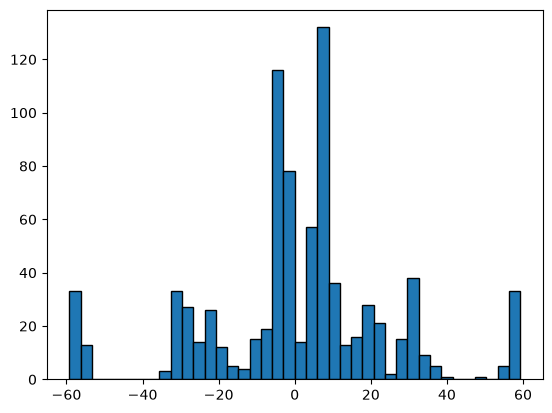

RODEO Group-1 lactone-formers kept: 412


In [15]:
from Bio.Align import PairwiseAligner, substitution_matrices
import matplotlib.pyplot as plt
from collections import Counter

aligner = PairwiseAligner(mode= "global")
aligner.substitution_matrix = substitution_matrices.load("BLOSUM62")
aligner.open_gap_score = -11
aligner.extend_gap_score = -1

def classify_bc(seq, mdnc_ref=query_seq, mdnb_ref=mdnb_seq, margin=3.0):   
    best_align_c = aligner.align(seq, mdnc_ref)[0]
    best_align_b = aligner.align(seq, mdnb_ref)[0]
    
    gapped_seq_c = best_align_c[0]
    gapped_ref_c = best_align_c[1]
    id_to_C = percent_identity_ungapped(gapped_seq_c, gapped_ref_c)
    
    gapped_seq_b = best_align_b[0]
    gapped_ref_b = best_align_b[1]    
    id_to_B = percent_identity_ungapped(gapped_seq_b, gapped_ref_b)

    diff = id_to_C - id_to_B

    if id_to_C - id_to_B > margin:
        return "C", diff
    elif id_to_B - id_to_C > margin:
        return "B", diff
    else:
        return "unsure", diff

# 1. Map every single sequence to its classification label (maintains 1-to-1 alignment)
rodeo_labels = []
diff_bc = []
for r in rodeo_g1:
    label, diff = classify_bc(str(r.seq))
    rodeo_labels.append(label)
    diff_bc.append(diff)                              
                              

# 2. Count the string labels (this successfully prints the C / B / unsure counts)
print(Counter(rodeo_labels)) 
                              
plt.hist(diff_bc, bins=40, edgecolor='black')
plt.show()                              

# 3. Zip using the aligned rodeo_labels list
rodeo_C = [r for r, label in zip(rodeo_g1, rodeo_labels) if label == "C"]
print(f"RODEO Group-1 lactone-formers kept: {len(rodeo_C)}")

---
## Part C — merge, band-filter, dedup  `[YOUR TURN — with all helpers provided]`

You have every helper you need (`mafft`, `percent_identity_ungapped`, `dedup`, `trim_all_gap_columns`). Wire them together. *Why this is yours:* the ordering and the threshold calls are the judgment — especially the RODEO relaxation below.

In [ ]:
# TODO(you): assemble the focused MdnC set. Print a line after each step to watch attrition.
#
#   1. pool = [query_record] + rodeo_C + blastwin
#   2. drop EXACT duplicate sequences (quick set on str(seq)) BEFORE aligning
#   3. aligned = mafft(pool, DATA / "mdnC_focused_raw_aligned.fasta")
#   4. compute identity-to-query FROM THE ALIGNMENT:
#         percent_identity_ungapped(str(aligned[0].seq), str(r.seq))
#      apply the 35-90 band HERE, uniformly for BLAST + RODEO seqs.
#      >>> RELAXATION: RODEO seqs are function-verified, so you MAY keep genuine lactone-formers
#          slightly below 35% (the floor there is about ALIGNMENT quality, not specificity).
#          Your call -- but not so low that MAFFT misplaces the alpha7 / beta9-beta10 columns.
#   5. dedup(kept, 90.0)              # near-duplicate removal
#   6. trim_all_gap_columns(kept)
#   7. SeqIO.write(kept, DATA / "mdnC_focused_aligned.fasta", "fasta")
#
# final = ...

---
## Part D — readiness diagnostic  `[compute FILLED · call is YOUR TURN]`

Count alone isn't the readiness test — the **identity distribution** is. Your broad run failed at median ~28% (too divergent → recognition residues wash out). The opposite failure is just as real: if lactone-formers cluster tightly and the set lands at median ~80%+, ConSurf can't discriminate rates and *everything* reads conserved. Aim to land mid-band.

In [ ]:
def identity_distribution(aligned_records):
    q = str(aligned_records[0].seq)
    ids = sorted(percent_identity_ungapped(q, str(r.seq)) for r in aligned_records[1:])
    if not ids: return None
    n = len(ids)
    return dict(n=n, min=round(min(ids)), q1=round(ids[n//4]),
                median=round(statistics.median(ids)), q3=round(ids[(3*n)//4]),
                max=round(max(ids)))

# TODO(you): run it on `final` and make the go/no-go call against these gates:
#   - count >= ~50 diverse seqs?  (if <50 -> enrich more RODEO / relax the floor)
#   - median ideally ~45-65%.  median > ~80% -> too tight (opposite of the broad-run failure).
# print(identity_distribution(final))

---
## Next

Upload **`data/mdnC_focused_aligned.fasta`** to ConSurf as a **custom MSA**, structure **PDB 5IG9, chain A**.

**Success check:** does **E191 / D192 / N195** climb toward conserved (grade ≥6, expected as acidic E/D — not necessarily 9), while the catalytic core (K125/K166/Q207/E215/D281/E294/N296) and **DxR R243** stay high? If yes, the focused set fixed the signal and you can read off new microviridin-specific positions.

**Then — the payoff analysis:** formally diff this focused map against the broad-run map. Residues high in *both* = universal (catalytic core, DxR). Residues that rise *only* in the focused run = microviridin-specific (the α7 cluster and whatever else surfaces). That broad-vs-focused contrast is arguably the most publishable single output of the project.

Commit: `"MdnC focused 35-90% microviridin lactone-former set (BLAST-window + RODEO)."`
